# Classification 2

## Exercise 1: Exploratory Data Analysis

### Overview

The objective of this course is to build models to predict customer churn for a fictitious telco company. Before we start creating models, let's begin by having a closer look at our data and doing some basic data wrangling.

Go through this notebook and modify the code accordingly (i.e. #TASK) based on the text and/or the comments.

### Data
Download data from here:
https://public.dhe.ibm.com/software/data/sw-library/cognos/mobile/C11/data/Telco_customer_churn.xlsx

Description of data (for a newer version)
https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113

### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# TASK: Import visualization libraries, matplotlib and seaborn using standard aliases plt and sns respectively

### Reading in the Data

In [5]:
# TASK: Read in the Excel file. Use the parameter na_values=" " to convert any empty cells to a NA value.
# You may also need to use parameter engine='openpyxl') in newer versions of pandas if you encounter an XLRD error.
data = pd.read_excel("Dataset/Telco_customer_churn.xlsx",
                     na_values= " ",
                     engine='openpyxl') # TASK: Use pandas to read in an Excel file.
print(data.head()) 

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [6]:
# Define columns to keep and filter the original dataset
cols_to_keep = ['CustomerID', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label']
data = data[cols_to_keep]

In [8]:
# TASK: Rename the multi-worded columns to remove the space 
# HINT: You can either manually remove the spaces in the column name list or use a loop to remove the space
data.columns = [col.replace(" ", "") for col in data.columns]
print(data.head())

   CustomerID  Gender SeniorCitizen Partner Dependents  TenureMonths  \
0  3668-QPYBK    Male            No      No         No             2   
1  9237-HQITU  Female            No      No        Yes             2   
2  9305-CDSKC  Female            No      No        Yes             8   
3  7892-POOKP  Female            No     Yes        Yes            28   
4  0280-XJGEX    Male            No      No        Yes            49   

  PhoneService MultipleLines InternetService OnlineSecurity  ...  \
0          Yes            No             DSL            Yes  ...   
1          Yes            No     Fiber optic             No  ...   
2          Yes           Yes     Fiber optic             No  ...   
3          Yes           Yes     Fiber optic             No  ...   
4          Yes           Yes     Fiber optic             No  ...   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1 

### Basic Information

In [9]:
# TASK: Display the number of rows and columns for the dataset
print("Rows & Columns: {}".format(data.shape))

Rows & Columns: (7043, 21)


In [10]:
# TASK: Display the datatypes for the columns in the dataframe i.e. use the dtypes variable
# How many columns are numerical and how many are non-numerical
data.dtypes

CustomerID              str
Gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
TenureMonths          int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
ChurnLabel              str
dtype: object

In [ ]:
# TASK: use count() on the dataframe to count the number of entries for each of the column. Are there any columns with missing values?
data.count()

CustomerID          7043
Gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
TenureMonths        7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7032
ChurnLabel          7043
dtype: int64

In [12]:
# TASK: Use nunique() on the dataframe to count the number of unique values for each of the columns
data.nunique()

CustomerID          7043
Gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
TenureMonths          73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
ChurnLabel             2
dtype: int64

In [13]:
# TASK: Display first few values of the dataframe
# Based on this and the previous display, how would you describe the columns with a small number (less than 10) of unique values?
print(data.head())

   CustomerID  Gender SeniorCitizen Partner Dependents  TenureMonths  \
0  3668-QPYBK    Male            No      No         No             2   
1  9237-HQITU  Female            No      No        Yes             2   
2  9305-CDSKC  Female            No      No        Yes             8   
3  7892-POOKP  Female            No     Yes        Yes            28   
4  0280-XJGEX    Male            No      No        Yes            49   

  PhoneService MultipleLines InternetService OnlineSecurity  ...  \
0          Yes            No             DSL            Yes  ...   
1          Yes            No     Fiber optic             No  ...   
2          Yes           Yes     Fiber optic             No  ...   
3          Yes           Yes     Fiber optic             No  ...   
4          Yes           Yes     Fiber optic             No  ...   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1 

In [17]:
# TASK: Let's analyze the values for the categorical features (columns with less than 10 unique values)
for id, row in data.nunique().items(): # this counts the number of unique values for each feature and returns the result as a dictionary
    if(row < 10):
        # TASK: Print out the unique values for the feature
        print(id, row, data[id].unique())

Gender 2 <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
SeniorCitizen 2 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Partner 2 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents 2 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService 2 <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
MultipleLines 3 <ArrowStringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
InternetService 3 <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity 3 <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
OnlineBackup 3 <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection 3 <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport 3 <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV 3 <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Streaming

In [18]:
# For columns with 3 or 4 unique values, display them to see if they make sense
for col in ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', "PaymentMethod"]:
    print("{} : {}".format(col, np.unique(data[col].values)))

MultipleLines : ['No' 'No phone service' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'No internet service' 'Yes']
OnlineBackup : ['No' 'No internet service' 'Yes']
DeviceProtection : ['No' 'No internet service' 'Yes']
TechSupport : ['No' 'No internet service' 'Yes']
StreamingTV : ['No' 'No internet service' 'Yes']
StreamingMovies : ['No' 'No internet service' 'Yes']
Contract : ['Month-to-month' 'One year' 'Two year']
PaymentMethod : ['Bank transfer (automatic)' 'Credit card (automatic)' 'Electronic check'
 'Mailed check']


**Observations**

- The value 'No phone service' found in MultipleLines is already captured by the PhoneService feature ('No' value)
- The value 'No internet service' found in the several features is already captured by InternetService feature ('No' value)
- Values that are longer or more complex may need to be simplified.

Conclusion: These values can be considered duplicated information as they are found in the PhoneService and InternetService features. There are several options to consider here:

- Retain all features and values as is
- Convert the 'No Internet Service'/'No phone service' to 'No' in the features as PhoneService and InternetService features has already captured this information
- Remove the PhoneService feature as MultipleLines feature has this information. To remove the InternetService feature, we would have to 'fold in' the values in the other features e.g. the values for OnlineSecurity could be changed to ['DSL_No','DSL_Yes','FiberOptic_No','FiberOptic_Yes','No internet service']

For this course, we will be using the second option (without justification). You are encouraged to test the others options during modelling to see if there are any impact.

### Data Wrangling

Based on the discoveries made above, we will be modifying our data before continuing the exploration.

In [19]:
# Replace 'No phone service'
data['MultipleLines'] = data['MultipleLines'].replace({'No phone service':'No'})

In [20]:
# TASK: Replace 'No internet service'
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    data[col] = data[col].replace({'No internet service':'No'}) # similar to the operation for 'No phone service' above

In [21]:
# Simplify the values made up of phrases
data['PaymentMethod'] = data['PaymentMethod'].replace({
    'Bank transfer (automatic)':'transfer',
    'Credit card (automatic)':'creditcard',
    'Electronic check':'echeck',
    'Mailed check':'mcheck'
})

data['InternetService'] = data['InternetService'].replace({
    'Fiber optic':'FiberOptic'
})

data['Contract'] = data['Contract'].replace({
    'Month-to-month':'M2M',
    'One year':'OneYear',
    'Two year':'TwoYear'
})

In [22]:
# Remove the rows with empty TotalCharges value
data = data[data["TotalCharges"].notnull()]

In [23]:
# After data wrangling, repeat prints
print("Rows & Columns: {}".format(data.shape))
print("################################################")
# Number of unique values for each of the columns
print(data.nunique())
print("################################################")
# Check the data types
print(data.dtypes)
print("################################################")
# Display first few values
print(data.head())

Rows & Columns: (7032, 21)
################################################
CustomerID          7032
Gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
TenureMonths          72
PhoneService           2
MultipleLines          2
InternetService        3
OnlineSecurity         2
OnlineBackup           2
DeviceProtection       2
TechSupport            2
StreamingTV            2
StreamingMovies        2
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
ChurnLabel             2
dtype: int64
################################################
CustomerID              str
Gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
TenureMonths          int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
T

In [24]:
# Randomly display 1 row from the dataframe
print(data.sample(n=1).iloc[0])

CustomerID          6786-OBWQR
Gender                  Female
SeniorCitizen               No
Partner                    Yes
Dependents                 Yes
TenureMonths                 5
PhoneService               Yes
MultipleLines               No
InternetService     FiberOptic
OnlineSecurity              No
OnlineBackup                No
DeviceProtection            No
TechSupport                 No
StreamingTV                Yes
StreamingMovies             No
Contract                   M2M
PaperlessBilling           Yes
PaymentMethod           echeck
MonthlyCharges           80.85
TotalCharges             356.1
ChurnLabel                  No
Name: 2415, dtype: object


In [25]:
# TASK: Save the data as a CSV fiile
data.to_csv("telco_churn.csv", index=False)

### Additional Exploration

**TASK:** This is the open-ended section of the exercise. Use any exploration techniques that you know to further explore and understand your data. We expect a number of visualizations that can show the relationships between features as well as between features and the outcome variable 'ChurnLabel'. Some of the questions in the quiz may require you to perform additional analyses.

/tmp/ipykernel_8635/4267008465.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(subset['MonthlyCharges'], hist = False, kde = True,
/home/robin/anaconda3/lib/python3.14/site-packages/seaborn/distributions.py:2496: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
/tmp/ipykernel_8635/4267008465.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
si

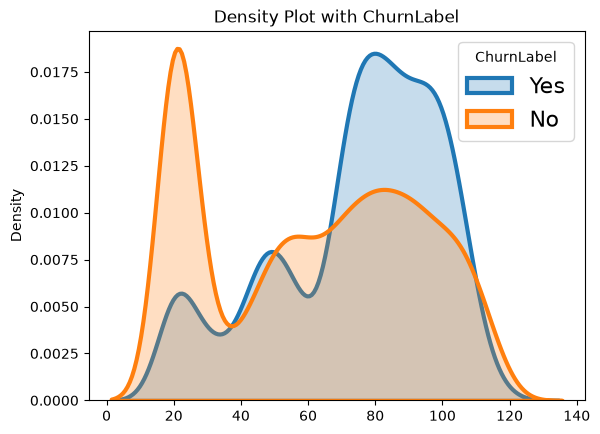

In [26]:
# Example: Look at Churn vs MonthCharges
plt.clf()
for label in ['Yes','No']:
    subset = data[data.ChurnLabel==label]
    
    # Draw the density plot
    sns.distplot(subset['MonthlyCharges'], hist = False, kde = True,
                 kde_kws = {'linewidth': 3, 'shade':True},
                 label = label)
    
# Plot formatting
plt.legend(prop={'size': 16}, title = 'ChurnLabel')
plt.title('Density Plot with ChurnLabel')
plt.xlabel('') # Monthly Charges
plt.ylabel('Density')
plt.show()

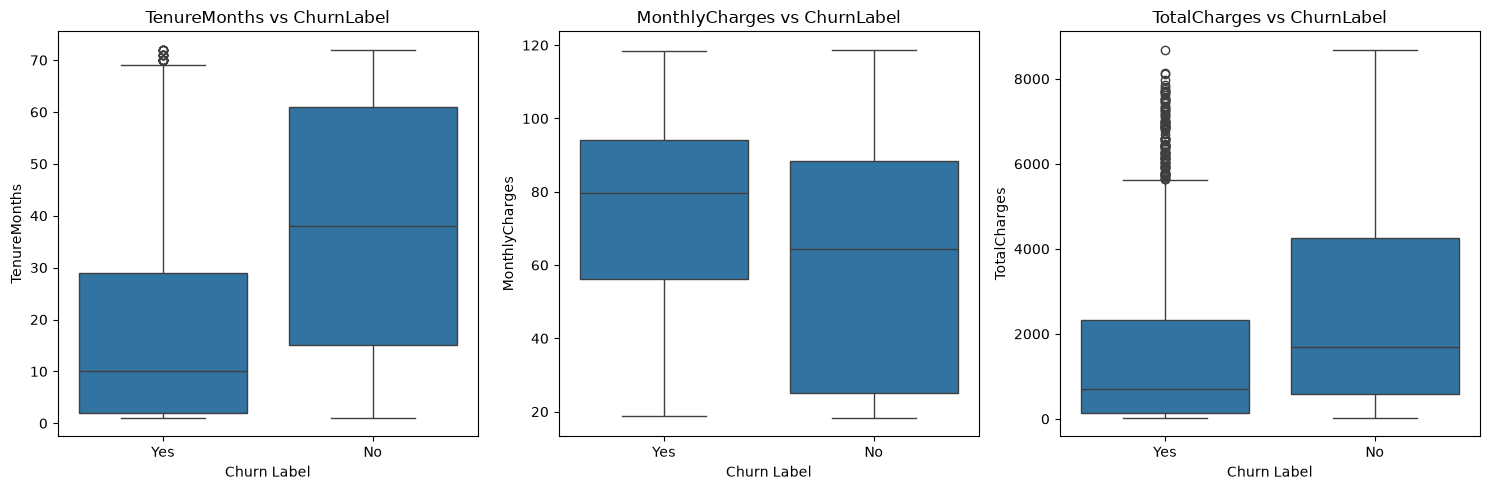

In [30]:
# Additional Exploration
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features
numerical_features = [
    "TenureMonths",
    "MonthlyCharges",
    "TotalCharges"
]

# Create Matplotlib figure with 3 columns
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# Create box plots
for i, feature in enumerate(numerical_features):

    sns.boxplot(
        data=data,
        x="ChurnLabel",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} vs ChurnLabel"
    )

    axes[i].set_xlabel("Churn Label")
    axes[i].set_ylabel(feature)

# Adjust spacing
plt.tight_layout()

In [37]:
import pandas as pd

cat_cols = [
    'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    'PhoneService', 'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Convert string 'ChurnLabel' to 1/0 integers on the fly
churn_numeric = (data['ChurnLabel'] == 'Yes').astype(int)

# 1. One-hot encode categorical features (Use pd.get_dummies)
df_encoded = pd.get_dummies(data[cat_cols], drop_first=False)

# 2. Compute Pearson correlation against Churn Value
churn_corr = df_encoded.corrwith(churn_numeric).sort_values(ascending=False)

# 3. View top positive (risk) and negative (retention) correlations
print("--- Top Churn Risk Drivers (Positive Correlation) ---")
print(churn_corr.head(10).round(3))

print("\n--- Top Retention Factors (Negative Correlation) ---")
print(churn_corr.tail(10).round(3))

--- Top Churn Risk Drivers (Positive Correlation) ---
Contract_M2M                  0.405
InternetService_FiberOptic    0.307
PaymentMethod_echeck          0.301
Dependents_No                 0.248
PaperlessBilling_Yes          0.191
OnlineSecurity_No             0.171
TechSupport_No                0.165
SeniorCitizen_Yes             0.151
Partner_No                    0.150
OnlineBackup_No               0.082
dtype: float64

--- Top Retention Factors (Negative Correlation) ---
PaymentMethod_creditcard   -0.135
Partner_Yes                -0.150
SeniorCitizen_No           -0.151
TechSupport_Yes            -0.165
OnlineSecurity_Yes         -0.171
Contract_OneYear           -0.178
PaperlessBilling_No        -0.191
InternetService_No         -0.228
Dependents_Yes             -0.248
Contract_TwoYear           -0.302
dtype: float64
